In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import re

In [2]:
df = pd.read_csv('cars.csv')

In [3]:
df

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Bright Silver Metallic,Blond,0.0,1.0,0.0,Volvo Cars Danbury,4.2,4.2,2.0,250.0,34798.0
762087,Volvo,S60 T5,2012,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,NaN,Red,Beige,NaN,NaN,NaN,NaN,NaN,4.5,101.0,NaN,12500.0
762088,Volvo,S60 T5,2014,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,Soft Beige,0.0,0.0,1.0,Dapper Car Sales,NaN,4.8,36.0,300.0,12299.0
762089,Volvo,S60 T5 Platinum,2013,132000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,All-wheel Drive,Gasoline,20-29,Ice White,Off Black,1.0,0.0,0.0,Legend Auto Sales Inc.,4.6,4.7,62.0,1000.0,8995.0


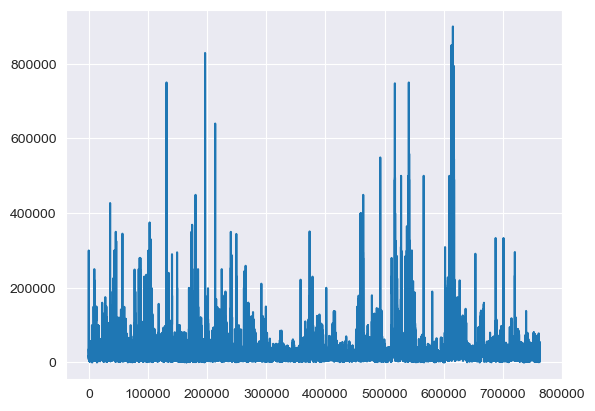

In [4]:
#Уберем малочисленные сильные выбросы цен
df = df[df["price"] < 1000000]
plt.plot(df["price"])

In [5]:
df.describe()

,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,price
count,762063.000000,7.615580e+05,737853.000000,730585.000000,737213.000000,548104.000000,730441.000000,762063.000000,410095.000000,762063.000000
mean,2017.791700,5.578259e+04,0.228621,0.561977,0.657208,4.158564,4.623527,89.553507,1006.994223,32489.027230
std,5.109891,4.355747e+04,0.419945,0.496144,0.474643,0.805744,0.276900,115.083305,1370.654890,22370.781442
min,1915.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,100.000000,1.000000
25%,2016.000000,2.328800e+04,0.000000,0.000000,0.000000,3.800000,4.500000,14.000000,380.000000,19581.000000
50%,2019.000000,4.559700e+04,0.000000,1.000000,1.000000,4.500000,4.700000,51.000000,642.000000,27989.000000
75%,2021.000000,7.836500e+04,0.000000,1.000000,1.000000,4.700000,4.800000,119.000000,1007.000000,39488.000000
max,2024.000000,1.119067e+06,1.000000,1.000000,1.000000,5.000000,5.000000,1025.000000,170995.000000,899975.000000


In [6]:
df.seller_name.value_counts()

seller_name
Gateway Classic Cars             1638
East Coast Auto Source           1061
Auto Boutique                     716
Adams North Charlotte             646
Automotive Avenues                637
                                 ... 
Teddy Volkswagen                    1
DCH Ford of Thousand Oaks           1
Orr Kia of Shreveport Bossier       1
ABELOFF KIA                         1
Daytona Kia                         1
Name: count, Length: 18254, dtype: int64

In [7]:
def print_nans_counts(df):
    for col in df.columns:
        na_counts = (df[col].isna()).sum()
        if na_counts > 0:
            print(f"---------------------\nColumn: {col}")
            print(f"Type {df[col].dtype}")
            print(f"Nan count: {na_counts}")

In [8]:
df.isna().sum().sort_values(ascending=False)

price_drop             351968
seller_rating          213959
mpg                    142061
interior_color          56966
driver_rating           31622
one_owner               31478
personal_use_only       24850
accidents_or_damage     24210
fuel_type               22924
drivetrain              21559
engine                  15050
transmission             9904
exterior_color           8859
seller_name              8592
mileage                   505
manufacturer                0
year                        0
model                       0
driver_reviews_num          0
price                       0
dtype: int64

In [9]:
def kfold_target_encode(df, col, target, n_splits=5, m=20):
    global_mean = df[target].mean()
    encoded = pd.Series(np.nan, index=df.index)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        # Считаем статистики ТОЛЬКО по train-части фолда
        train = df.iloc[train_idx]
        agg = train.groupby(col)[target].agg(['mean', 'count'])

        # Encoding со сглаживанием
        mapping = (
            (agg['count'] * agg['mean'] + m * global_mean) /
            (agg['count'] + m)
        )

        # Применяем к val-части фолда
        encoded.iloc[val_idx] = df.iloc[val_idx][col].map(mapping)

    # Новые категории (не встретились в фолде) — global_mean
    encoded.fillna(global_mean, inplace=True)
    return encoded

def target_encode_test(train, test, col, target, m=20):
    global_mean = train[target].mean()
    agg = train.groupby(col)[target].agg(['mean', 'count'])

    mapping = (
        (agg['count'] * agg['mean'] + m * global_mean) /
        (agg['count'] + m)
    )

    encoded = test[col].map(mapping).fillna(global_mean)
    return encoded

In [10]:
def get_train_type(s):
    s = str(s).lower()
    if re.match(r".*(all|four|4wd|awd)", s):
        return "AWD"
    elif re.match(r".*(front|fwd)", s):
        return "FWD"
    elif re.match(r".*(rear|rwd)", s) or re.match(r".*m.?t", s):
        return "RWD"
    return "Unknown"

def get_trans_type(s):
    s = str(s).lower()
    if re.match(r".*cvt", s) or re.match(r".*variable.*", s) or re.match(r".*ivt.*", s):
        return "CVT"
    elif re.match(r".*a.?t", s):
        return "AT"
    elif re.match(r".*man", s) or re.match(r".*m.?t", s):
        return "MT"
    elif re.match(r".*DCT", s) or re.match(r".*dual", s):
        return "DCT"
    return "Unknown"

def get_fuel_type(s):
    s = str(s).lower()
    if re.match(r".*(hybrid|phev|4wd|electric fuel)", s):
        return "Hybrid"
    elif re.match(r".*(natural)", s):
        return "Natural Gas"
    elif re.match(r".*(gasoline|gas|unleaded)", s):
        return "Gasoline"
    elif re.match(r".*(flex|e85)", s):
        return "Flex Fuel"
    elif re.match(r".*(diesel)", s):
        return "Diesel"
    elif re.match(r".*(electric)", s):
        return "Electic"
    return "Unknown"

def split_mpg(s):
    left = None
    right = None
    if s:
        s = str(s).lower()
        split_res = s.split("-")
        if len(split_res) == 2:
            left, right = split_res
        elif len(split_res) == 1:
            left, right = split_res[0], split_res[0]
        left = float(left)
        right = float(right)
    return pd.Series([left, right])

In [11]:
desc = [['black', ['black', 'noir', 'onyx', 'caviar', 'ebony', 'dark']],
              ['white', ['white', 'blanc', 'pearl', 'whiite', 'fresh powder', 'light']],
              ['silver', ['silver']],
              ['gray', ['gray', 'grey', 'charcoal', 'graphite', 'slate', 'ash', 'stone', 'cement']],
              ['red', ['red', 'burgundy', 'maroon', 'cherry', 'crimson', 'scarlet ember', 'cognac']],
              ['blue', ['blue', 'navy', 'indigo', 'lunar', 'area 51']],
              ['green', ['green', 'emerald', 'olive']],
              ['brown', ['brown', 'tan', 'espresso', 'bronze', 'chocolate', 'mocha', 'cocoa']],
              ['yellow', ['yellow', 'gold', 'champagne']],
              ['orange', ['orange', 'copper', 'sand', 'dune']],
              ['purple', ['purple', 'violet']],
              ['metal', ['metal', 'steel', 'platinum', 'pewter', 'magnetic', 'billet']],
              ['beige', ['beige', 'birch', 'ivory', 'parchment', 'wheat', 'sandstone', 'cappuccino', 'almond', 'blond', 'taupe', 'cream']],
              ]

def simplify_color(s):
    if s == None:
        return "Unknown"
    s = str(s).lower()
    res = 'other'

    for pal in desc:
        for col in pal[1]:
            if col in s:
                res = pal[0]
                break
        if res != 'other':
            break
    return res

In [12]:
def heavy_preps(df):
    prep = df.copy(deep=True)
    prep[["mpg_l", "mpg_r"]] = prep["mpg"].apply(split_mpg)
    prep.drop(columns=["mpg"], inplace=True)
    return prep


In [13]:
def prepare_data(df):
    prep = df.copy(deep=True)

    prep.drop(prep[prep.mileage > 800000].index, inplace=True)
    prep.fillna({"mileage": prep.mileage.mean()}, inplace=True)
    prep["mileage"] = (prep["mileage"] / 800000)
    prep["mileage"] = prep["mileage"].pow(0.3206534790699)

    prep = prep[prep["year"] >= 2000]
    prep["year"] = (prep["year"] - prep["year"].min()) / (prep["year"].max() - prep["year"].min())
    prep["year"] = prep["year"].pow(4.764746051087997)

    prep["engine_l"] = prep["engine"].str.extract(r"(\d+\.?\d*)\s*L").astype(float)
    prep["dt_type"] = prep["drivetrain"].apply(get_train_type)
    prep["tm_type"] = prep["transmission"].apply(get_trans_type)
    prep["fu_type"] = prep["fuel_type"].apply(get_fuel_type)

    prep["int_col_simp"] = prep["interior_color"].apply(simplify_color)
    prep["ext_col_simp"] = prep["exterior_color"].apply(simplify_color)
    #prep.fillna({"int_col_simp" : "AAAA", "ext_col_simp" : "AAAA"}, inplace=True)

    prep.drop(columns=["engine", "drivetrain", "transmission", "fuel_type", "interior_color", "exterior_color"], inplace=True)



    return prep

In [14]:
def fill_blanks(df):
    prep = df.copy(deep=True)

    prep.fillna({"accidents_or_damage" : 0, "one_owner" : 1, "personal_use_only" : 0}, inplace=True)
    prep.fillna({"seller_rating" : prep.seller_rating.median(), "driver_rating" : prep.driver_rating.median()}, inplace=True)
    prep.fillna({"mpg_l" : prep.mpg_l.median(), "mpg_r" : prep.mpg_r.median(), "engine_l" : prep.engine_l.median()}, inplace=True)

    prep.drop(columns=["model", "seller_name", "price_drop", "seller_rating"], inplace=True, errors="ignore")

    return prep

In [15]:
def encode_categorial(train, test, target, columns_dict, n_splits=5):
    for col, m_val in columns_dict.items():
        print(col, m_val)
        encoded = kfold_target_encode(train, col, target, n_splits=n_splits, m=m_val)
        train.loc[:,col + '_enc'] = encoded

        encoded = target_encode_test(train, test, col, target, m=m_val)
        test.loc[:,col + '_enc'] = encoded

        train.drop(columns=[col], inplace=True)
        test.drop(columns=[col], inplace=True)


In [16]:
df_prot = heavy_preps(df)
#df_prot.drop(columns=["model", ""], inplace=True)

In [17]:
df_exp = prepare_data(df_prot)
df_exp = fill_blanks(df_exp)
df_exp

,manufacturer,year,mileage,accidents_or_damage,one_owner,personal_use_only,driver_rating,driver_reviews_num,price,mpg_l,mpg_r,engine_l,dt_type,tm_type,fu_type,int_col_simp,ext_col_simp
0,Acura,0.053864,0.501456,0.0,0.0,0.0,4.4,12.0,13988.0,39.0,38.0,1.5,FWD,AT,Gasoline,beige,black
1,Acura,0.053864,0.404740,1.0,1.0,1.0,4.4,12.0,17995.0,39.0,38.0,1.5,FWD,CVT,Hybrid,black,gray
2,Acura,0.053864,0.419869,0.0,1.0,1.0,4.4,12.0,17000.0,39.0,38.0,1.5,FWD,CVT,Hybrid,black,white
3,Acura,0.053864,0.540748,0.0,1.0,1.0,4.4,12.0,14958.0,39.0,38.0,1.5,FWD,CVT,Hybrid,other,metal
4,Acura,0.053864,0.536686,1.0,0.0,1.0,4.4,12.0,14498.0,39.0,38.0,1.5,FWD,CVT,Hybrid,black,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,0.660613,0.319897,0.0,1.0,0.0,4.2,2.0,34798.0,25.0,33.0,2.0,AWD,AT,Gasoline,beige,silver
762087,Volvo,0.036785,0.463878,0.0,1.0,0.0,4.5,101.0,12500.0,20.0,28.0,2.5,FWD,AT,Gasoline,beige,red
762088,Volvo,0.076675,0.499815,0.0,0.0,1.0,4.8,36.0,12299.0,21.0,30.0,2.5,FWD,AT,Gasoline,beige,white
762089,Volvo,0.053864,0.561156,1.0,0.0,0.0,4.7,62.0,8995.0,20.0,29.0,2.5,AWD,AT,Gasoline,black,white


In [18]:
df_train, df_test = train_test_split(df_exp, test_size=0.2, random_state=228)
df_test

,manufacturer,year,mileage,accidents_or_damage,one_owner,personal_use_only,driver_rating,driver_reviews_num,price,mpg_l,mpg_r,engine_l,dt_type,tm_type,fu_type,int_col_simp,ext_col_simp
282952,GMC,0.529277,0.432309,0.0,1.0,0.0,4.6,22.0,24254.0,25.0,28.0,1.5,AWD,AT,Gasoline,black,white
268122,Ford,0.419490,0.436671,1.0,0.0,0.0,3.8,9.0,25995.0,24.0,27.0,2.0,FWD,AT,Gasoline,other,white
430165,Kia,0.419490,0.460247,1.0,0.0,0.0,4.8,69.0,21195.0,24.0,32.0,2.4,FWD,AT,Gasoline,black,white
201875,Ford,0.253921,0.425200,0.0,0.0,0.0,4.8,824.0,31000.0,18.0,23.0,2.7,AWD,AT,Gasoline,other,white
445346,Kia,0.660613,0.239746,0.0,1.0,0.0,4.5,5.0,19998.0,33.0,41.0,1.6,FWD,CVT,Gasoline,black,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660413,Subaru,0.419490,0.407630,0.0,1.0,1.0,4.9,34.0,29988.0,24.0,32.0,2.5,AWD,CVT,Gasoline,other,white
258220,Ford,0.106517,0.546582,0.0,0.0,1.0,4.6,297.0,13495.0,22.0,29.0,2.0,AWD,AT,Gasoline,black,blue
526621,Mercedes-Benz,0.419490,0.339882,0.0,1.0,0.0,4.9,13.0,30998.0,24.0,34.0,2.0,FWD,AT,Gasoline,black,red
614787,Porsche,0.144867,0.244431,0.0,0.0,1.0,4.8,9.0,135000.0,18.0,26.0,3.8,AWD,AT,Gasoline,other,white


In [19]:

categorial_columns = {"manufacturer" : 5, "dt_type" : 5, "tm_type" : 5, "fu_type" : 5, "int_col_simp" : 5, "ext_col_simp" : 5}
n_splits = 3

encode_categorial(df_train, df_test, "price", categorial_columns, n_splits=5)
df_train

manufacturer 5
dt_type 5
tm_type 5
fu_type 5
int_col_simp 5
ext_col_simp 5


,year,mileage,accidents_or_damage,one_owner,personal_use_only,driver_rating,driver_reviews_num,price,mpg_l,mpg_r,engine_l,manufacturer_enc,dt_type_enc,tm_type_enc,fu_type_enc,int_col_simp_enc,ext_col_simp_enc
19665,0.253921,0.355681,0.0,1.0,0.0,4.7,181.0,34998.0,23.0,27.0,2.0,36467.194252,37870.302426,33863.616214,31304.113533,33506.372761,30165.745905
119874,0.529277,0.445286,0.0,0.0,0.0,4.5,27.0,18988.0,24.0,32.0,1.4,31300.278927,21464.583717,33865.098160,31322.865579,33503.879856,33838.314723
357450,0.660613,0.197148,0.0,1.0,1.0,4.4,9.0,37992.0,22.0,28.0,2.5,21603.076356,21437.901883,33863.616214,31304.113533,33506.372761,34098.467018
189389,0.419490,0.272152,0.0,0.0,1.0,4.8,47.0,41995.0,18.0,25.0,5.7,27091.557517,37871.085312,33894.871204,31356.481275,33539.082760,34092.352422
604164,0.660613,0.133530,0.0,0.0,0.0,4.5,7.0,29455.0,20.0,28.0,2.0,23577.254093,37864.990576,24343.835075,31322.865579,26569.435391,30490.676750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123341,0.419490,0.343246,0.0,1.0,1.0,4.6,139.0,44022.0,20.0,23.0,3.0,31253.262131,37871.085312,33894.871204,53068.950435,33539.082760,28446.254610
588123,0.660613,0.160281,1.0,1.0,0.0,4.0,4.0,22880.0,31.0,36.0,1.6,23521.043013,21454.542122,24318.946153,31324.254238,26576.015136,32304.768404
405699,0.529277,0.360647,0.0,0.0,0.0,4.6,50.0,26759.0,22.0,30.0,2.4,31273.030094,37871.085312,33894.871204,31356.481275,33539.082760,33890.016050
340154,0.144867,0.463382,0.0,1.0,0.0,4.5,76.0,18995.0,19.0,25.0,2.4,21595.332112,37823.504362,33854.322258,31303.234411,26555.949206,33828.023416


<Axes: >

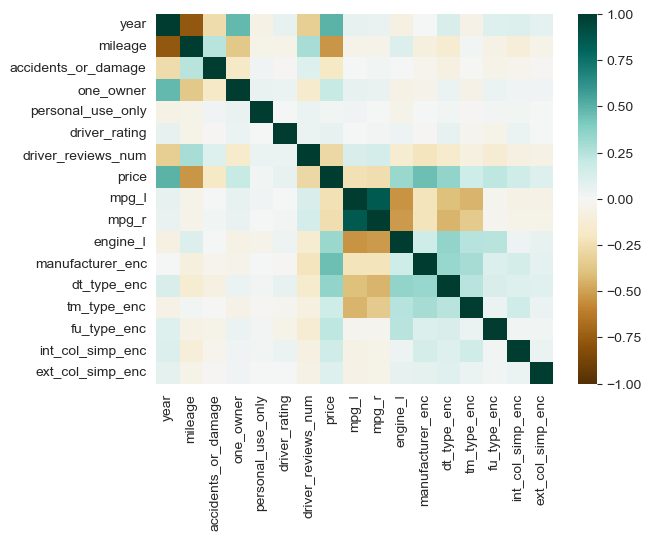

In [20]:
#Рассмотрим матрицу корреляций после всех изменений

num_cols = df_train.loc[:, df_train.dtypes != object].columns

sns.heatmap(
    df_train[num_cols].corr(),
    vmin=-1,
    vmax=1,
    cmap='BrBG'
)

#Как видно, линейные модели скорее всего претерпят неудачу, будем пытаться в ансамбли

In [21]:
X_train = df_train.drop(columns=["price"])
X_test = df_test.drop(columns=["price"])

y_train = df_train["price"]
y_test = df_test["price"]

In [22]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

model_lr = LinearRegression()
#model = RandomForestRegressor()
model_lr.fit(X_train, y_train)

LinearRegression()

In [50]:
y_pred = model_lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 7684.919883688096
RMSE: 14433.65426669735
R2: 0.5696191044474466


In [72]:
from sklearn.linear_model import Ridge, Lasso

model_ridge = Ridge(alpha=3.5)
model_ridge.fit(X_train, y_train)

Ridge(alpha=3.5)

In [73]:
y_pred = model_ridge.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 7682.323991888087
RMSE: 14428.784320018452
R2: 0.569909478373301


In [80]:
model_lasso = Lasso(alpha=4)
model_lasso.fit(X_train, y_train)

Lasso(alpha=4)

In [81]:
y_pred = model_lasso.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 7678.313262777573
RMSE: 14425.33685829944
R2: 0.5701149764171158


In [24]:
from sklearn.tree import DecisionTreeRegressor

model_dtr = DecisionTreeRegressor(max_depth=30, min_samples_split=30, min_samples_leaf=10)
model_dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=30, min_samples_leaf=10, min_samples_split=30)

In [25]:
from sklearn.model_selection import cross_val_score

y_pred = model_dtr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 3211.209306632144
RMSE: 6823.677047388929
R2: 0.9038083627493736


In [115]:
from sklearn.ensemble import BaggingRegressor, StackingRegressor

estimators = [
    ('linear', LinearRegression()),
    ('tree', DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=5))
]

model_br = StackingRegressor(estimators=estimators)
model_br.fit(X_train, y_train)

StackingRegressor(estimators=[('linear', LinearRegression()),
                              ('tree',
                               DecisionTreeRegressor(max_depth=5,
                                                     min_samples_leaf=5,
                                                     min_samples_split=5))])

In [116]:
y_pred = model_br.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 6859.180682436882
RMSE: 12598.82291754337
R2: 0.6720857184193061


In [117]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(loss='squared_error',max_depth=3, n_estimators=100, random_state=42, learning_rate=0.1, criterion='squared_error')
gbr.fit(X_train, y_train)

GradientBoostingRegressor(criterion='squared_error', random_state=42)

In [118]:
y_pred = model_br.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 6859.180682436882
RMSE: 12598.82291754337
R2: 0.6720857184193061


In [126]:
'''

лИНЕЙНАЯ РЕГРЕССИЯ
лОГИСТИЧЕСКАЯ -//-
SVM
KNN
Дерево решений
Случайный лес (bagging)


Ансамблевые методы
Bagging
Stacking
boosting
gradient boosting


PCA - сингулярное разложение
TSNE
U-map

наивный bias


Кластеризация
Классификация - переделать задачу
'''